In [1]:
import numpy as np
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

from SSA2 import SSAv3


%matplotlib inline

In [2]:
data105 = pd.read_csv('brent-daily_csv.csv', parse_dates=True, index_col='Date',encoding="windows-1252") # или 106.csv
data105.head(5)

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [3]:
# Выбор периода с выбранной частотой
# 1=1min 2=2min, 10=10min, 60=1hour, 720=12hour, 1440=1day, 10080=1week, 44640=1month

# 2019-04-09 01:01:00':'2020-04-04 01:01:00

# Частота №=2----------------------------------------------------------------------------------------\
period2=data105['2000-01-01':'2020-05-01'][::1]
per_temp2 = period2  #24     48
per_temp2

,Price
Date,
2000-01-04,23.95
2000-01-05,23.72
2000-01-06,23.55
2000-01-07,23.35
2000-01-10,22.77
...,...
2020-04-27,15.17
2020-04-28,15.60
2020-04-29,17.86


In [4]:
# plt.figure()
# per_temp2.plot(figsize=[20,7])
# #per_temp2.plot(style='k.')
# plt.title('Температура выбранного периода №1', fontsize=20)
# plt.grid(True)
# plt.ylabel('Температура ($^oC$)',fontsize=15)
# plt.xlabel('Период',fontsize=15)
# plt.legend()

In [5]:
means105 = per_temp2.groupby(pd.Grouper(freq='MS')).mean()  # ПЕРИОД
means105

,Price
Date,
2000-01-01,25.511000
2000-02-01,27.775714
2000-03-01,27.486087
2000-04-01,22.764444
2000-05-01,27.737619
...,...
2020-01-01,63.645455
2020-02-01,55.657000
2020-03-01,32.011364


In [6]:
#pd.set_option('display.max_rows', 500)

per_temp105 = means105['Price']  #24     48 ТЕМПЕРАТУРА

per_temp105

Date
2000-01-01    25.511000
2000-02-01    27.775714
2000-03-01    27.486087
2000-04-01    22.764444
2000-05-01    27.737619
                ...    
2020-01-01    63.645455
2020-02-01    55.657000
2020-03-01    32.011364
2020-04-01    18.378500
2020-05-01    18.490000
Freq: MS, Name: Price, Length: 245, dtype: float64

In [7]:
per_temp105.interpolate(method='linear', inplace=True)


In [8]:
# Using plotly.express
import plotly.express as px

import pandas as pd

fig = px.line(per_temp105, title='Температура выбранного периода ст. 105')
fig.show()

In [9]:
ssa = SSAv3(per_temp105) #
[x for x in dir(ssa) if '__' not in x and x[0]!='_']

['SVD',
 'diagonal_averaging',
 'embed',
 'forecast_recurrent',
 'freq',
 'getcontributions',
 'ts',
 'ts_N',
 'ts_name',
 'ts_v',
 'view_reconstruction',
 'view_s_contributions',
 'view_time_series']

In [10]:
K = 40 #+ матрица
seasonality = 12 # подозреваемая сезонность (12) 4 особо не влияет

In [11]:
ssa.embed(embedding_dimension=40, frequency=seasonality, verbose=True) # ИЗМЕНИТЬ ОБЯЗ 120 /40 стандартное
#         размер вложения         подозреваемая частота=подозреваемая сезонность


In [12]:
ssa.SVD(verbose=True)


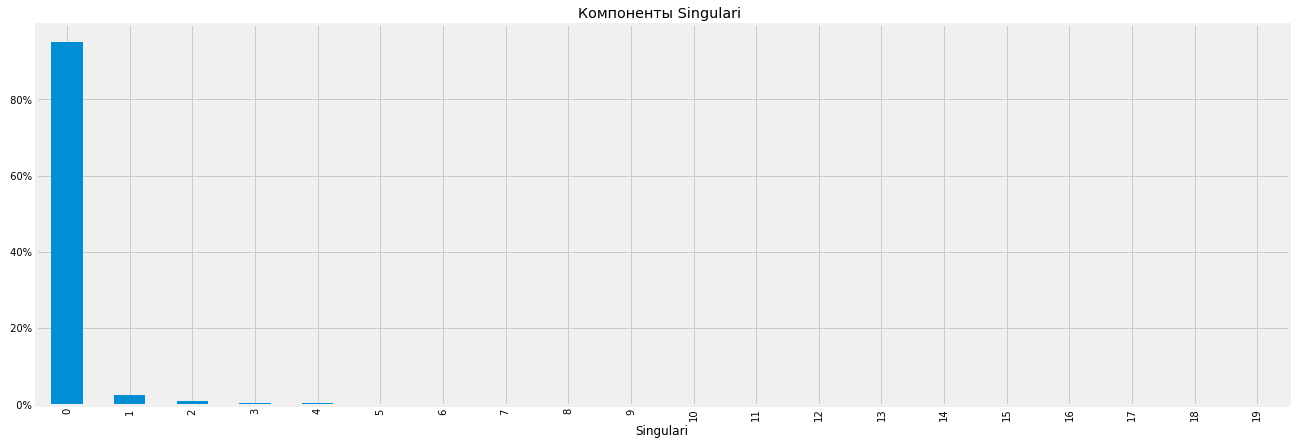

In [13]:
%matplotlib inline 
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20, 7 

ssa.view_s_contributions()


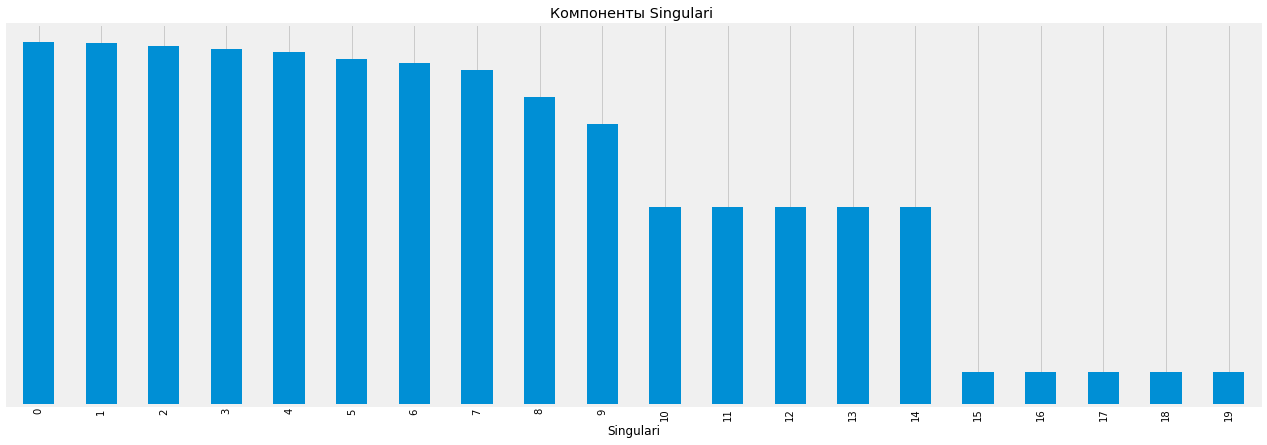

In [14]:
ssa.view_s_contributions(adjust_scale=True)


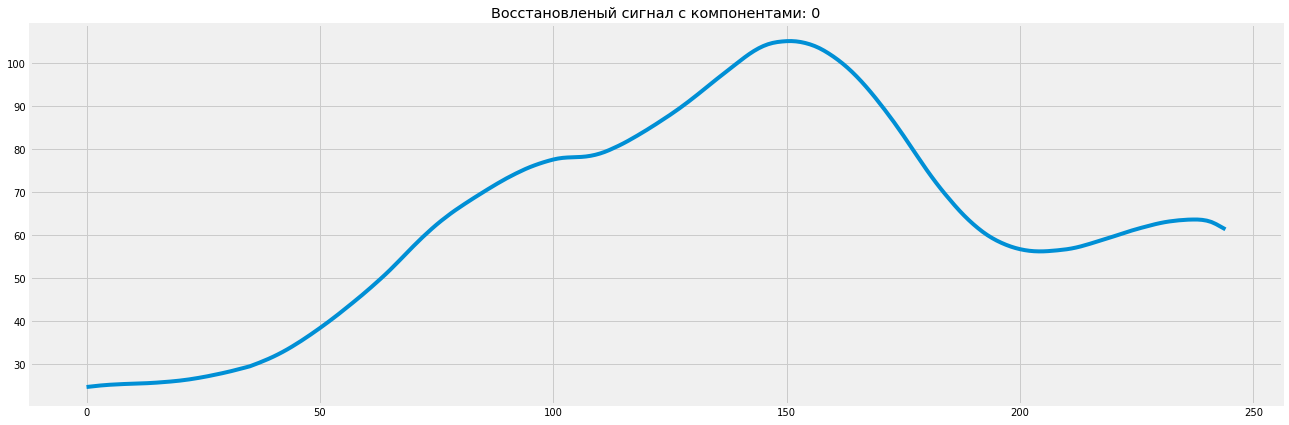

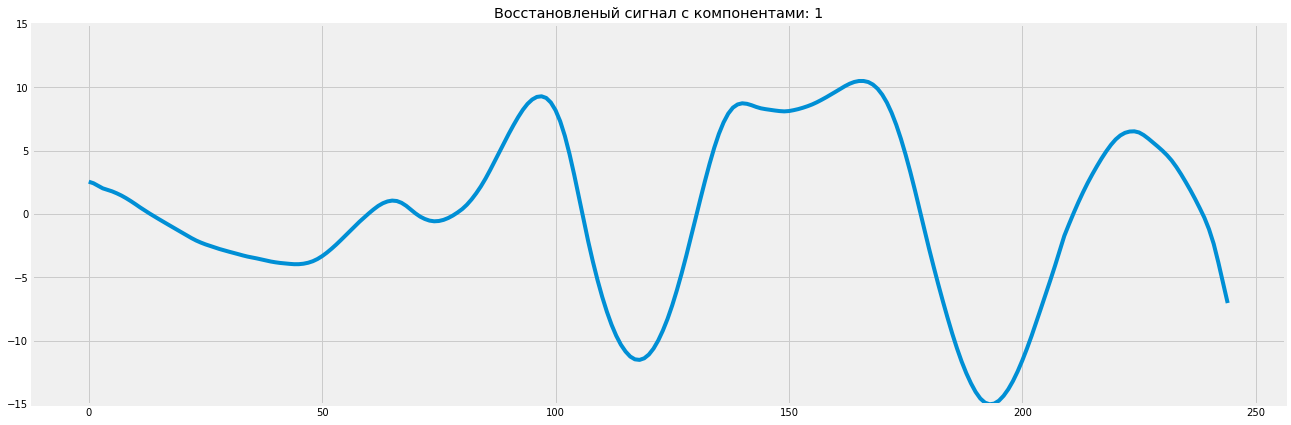

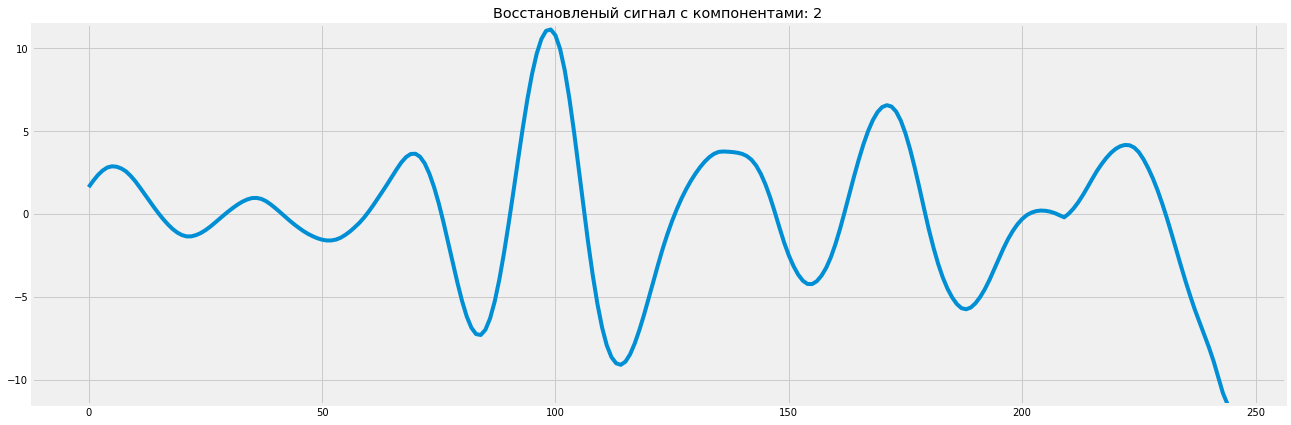

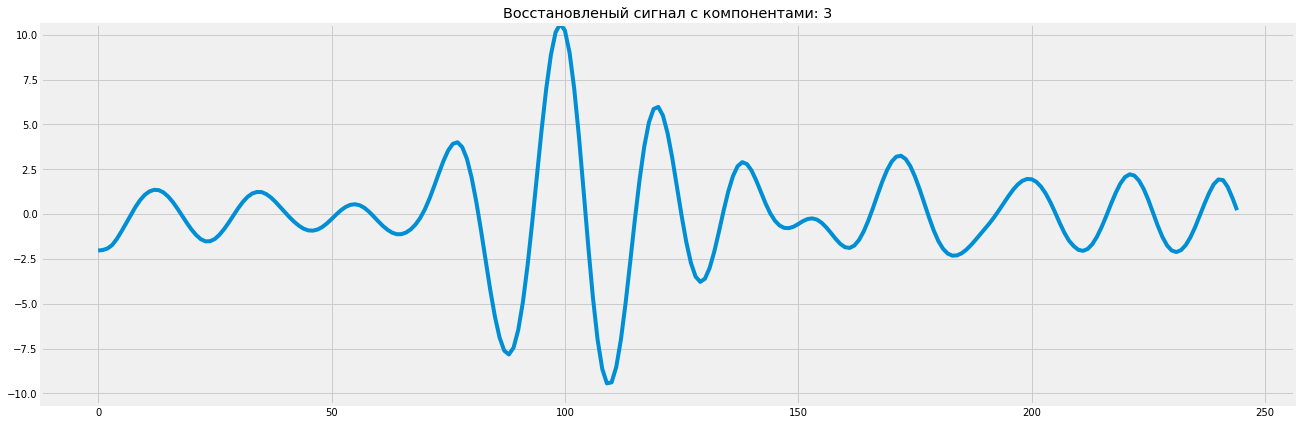

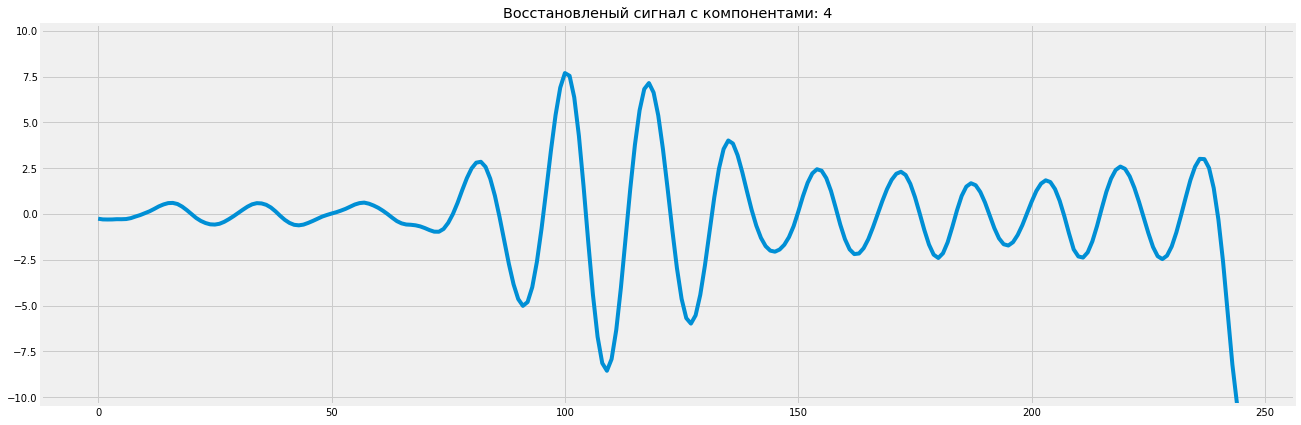

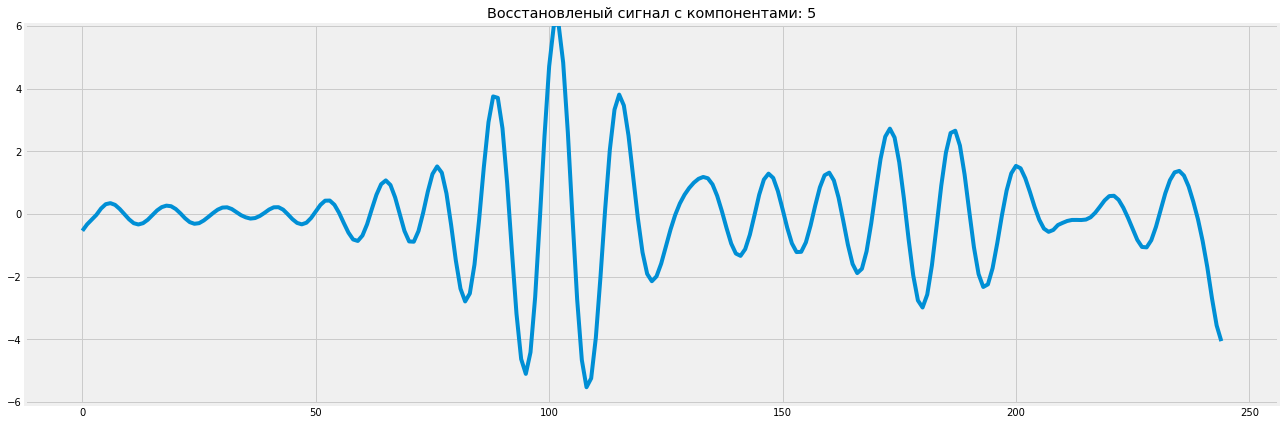

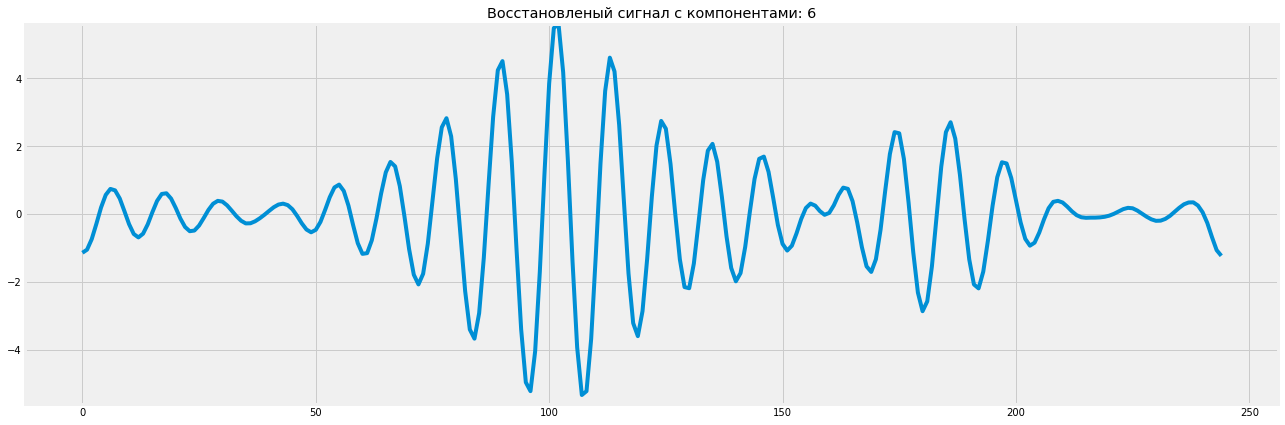

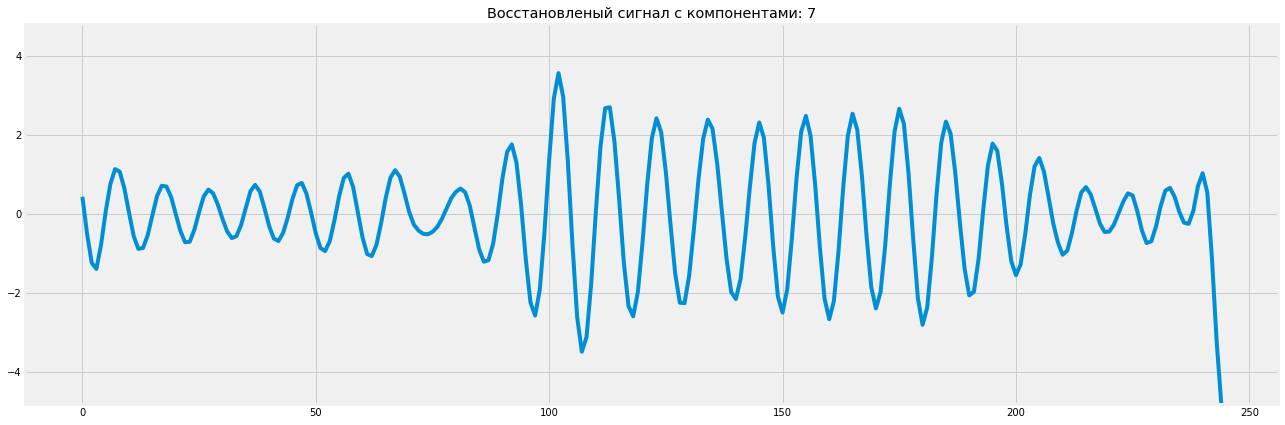

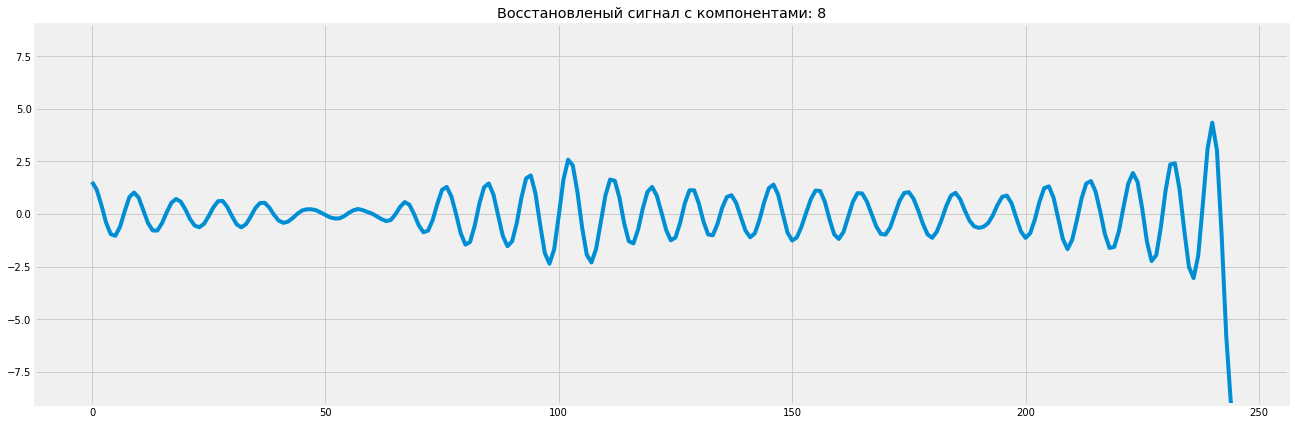

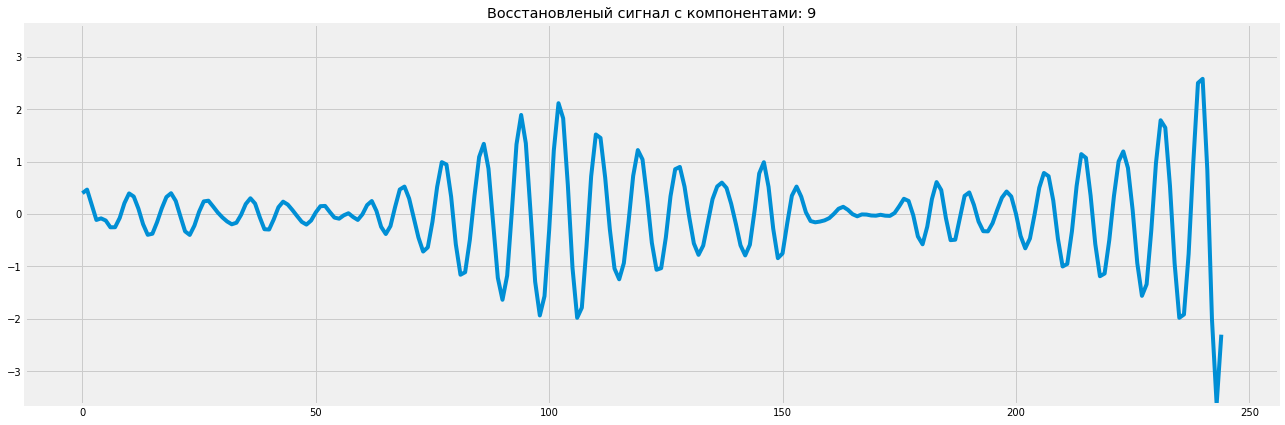

In [15]:
for i in range(10): # количество компонентов \ ИЗМЕНЯЕТСЯ ВОЗМОЖНЫ ОШИБКИ
    ssa.view_reconstruction(ssa.Xs[i], names=i, symmetric_plots=i!=0)
# Можно скрыть

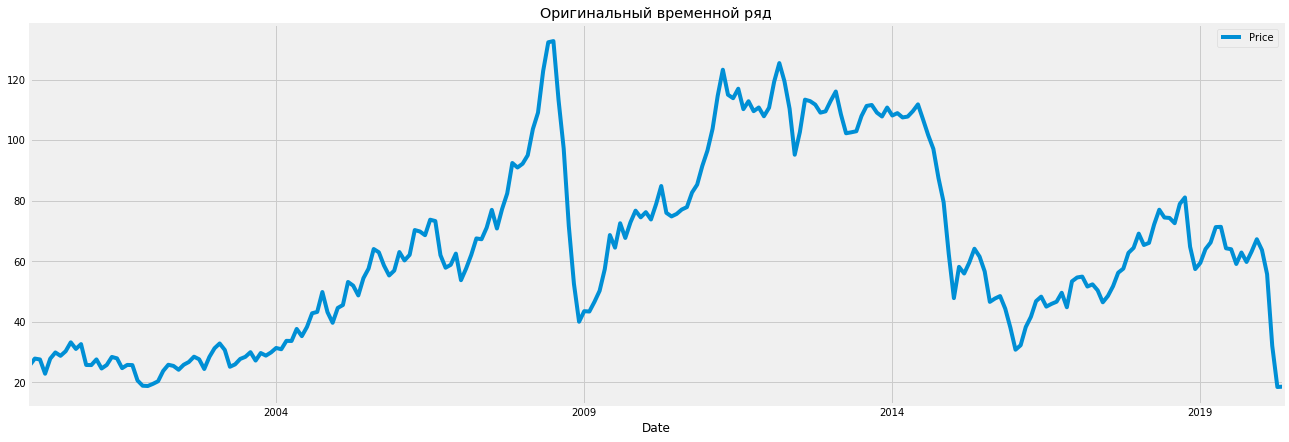

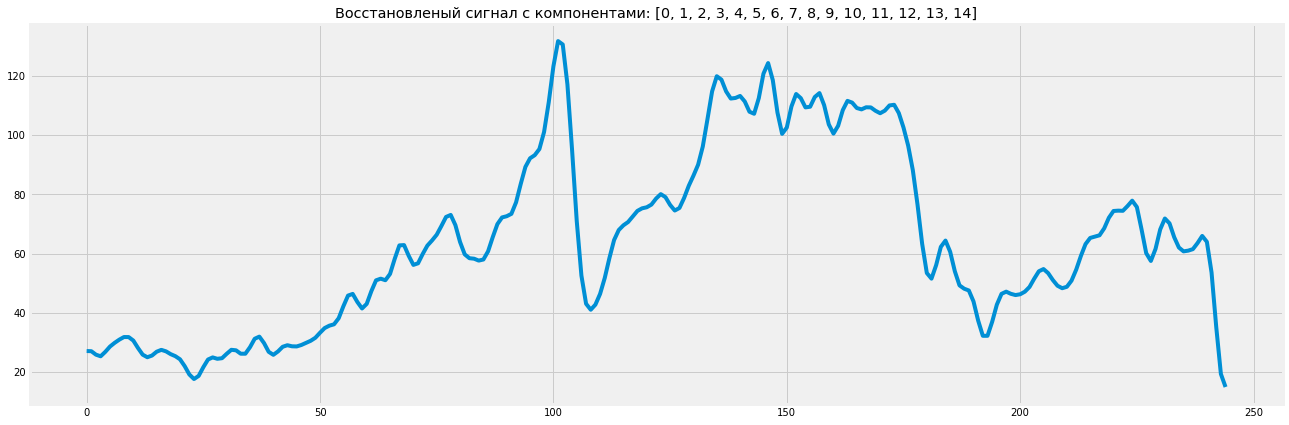

In [16]:
ssa.ts.plot(title='Оригинальный временной ряд'); # оригинальный график для сравнения
streams1 = [i for i in range(15)] # количество компонентов.
reconstructed1 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams1], names=streams1, return_df=True)


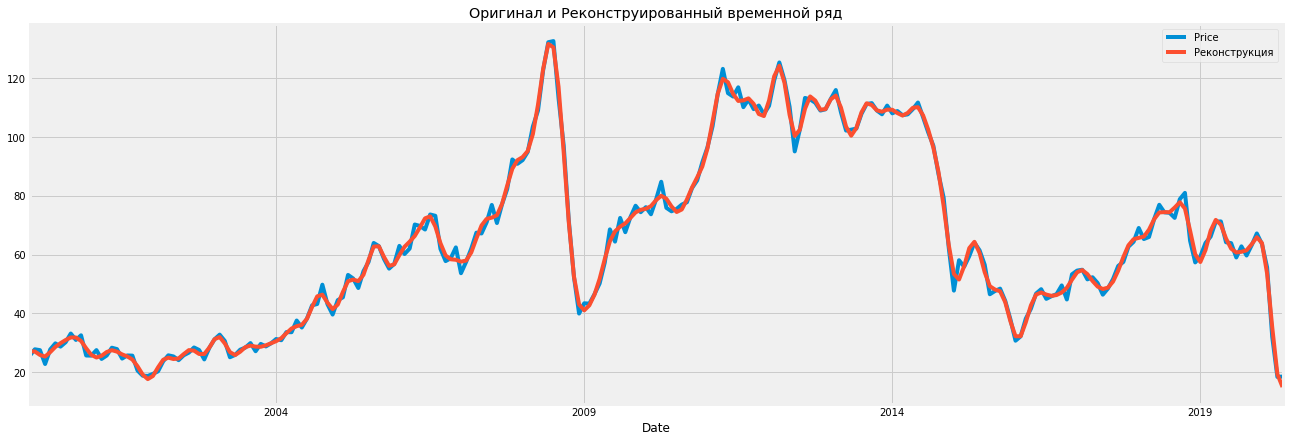

In [17]:
ts_copy1 = ssa.ts.copy()
ts_copy1['Реконструкция'] = reconstructed1.Reconstruction.values
ts_copy1.plot(title='Оригинал и Реконструированный временной ряд');


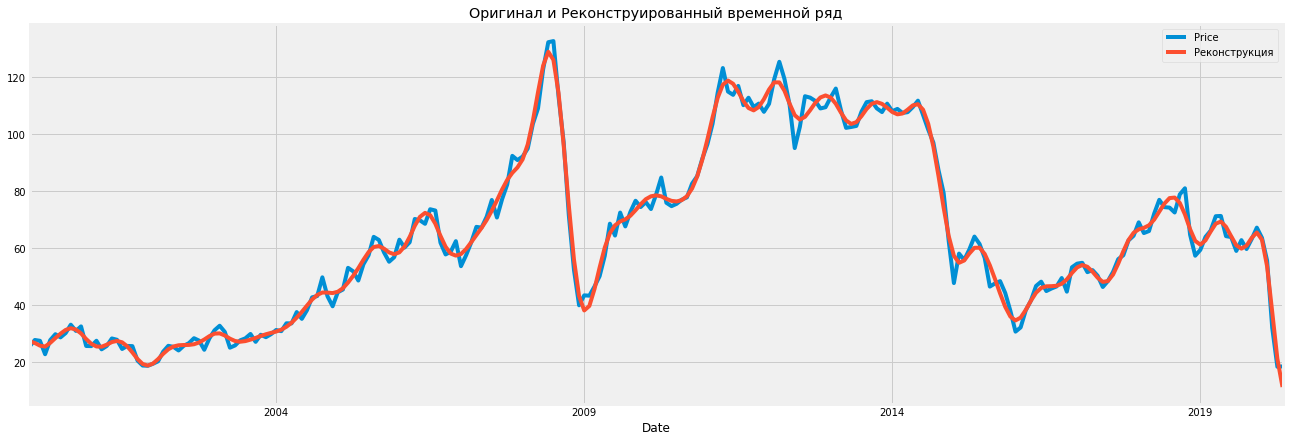

In [18]:
streams2 = [i for i in range(10)] # 10 стандарт. При выборке в 60 ставится 18. Количество выбранных значений для реконструкции
reconstructed2 = ssa.view_reconstruction(*[ssa.Xs[i] for i in streams2], 
                                          names=streams2, return_df=True, plot=False)
ts_copy2 = ssa.ts.copy()
ts_copy2['Реконструкция'] = reconstructed2.Reconstruction.values
ts_copy2.plot(title='Оригинал и Реконструированный временной ряд');


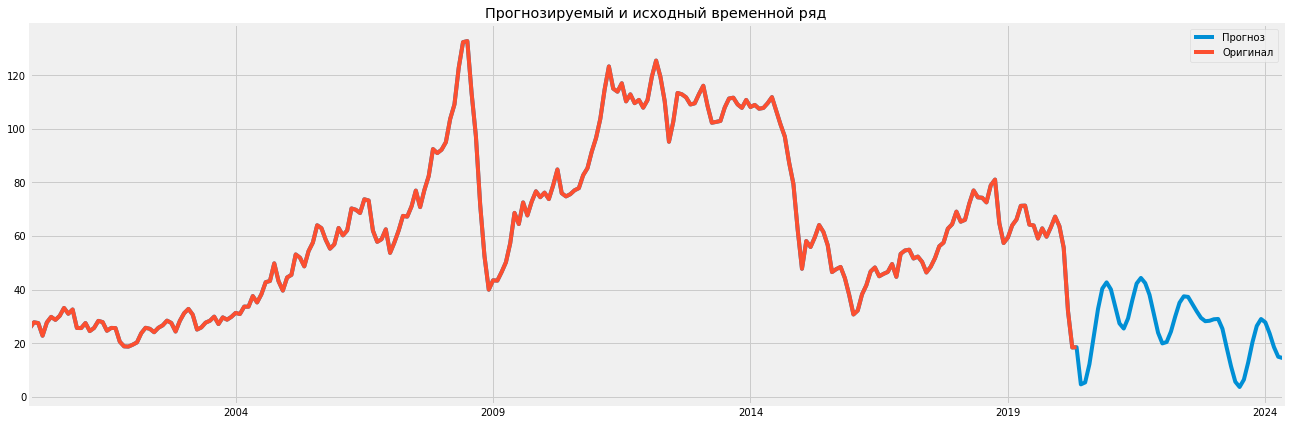

In [19]:
ssa.forecast_recurrent(steps_ahead=48, singular_values=streams2, plot=True) #48 количество прогнозируемых значений (60 дней))
